<table  align="left" width="100%"> <tr>
        <td  style="background-color:#ffffff;"><a href="https://qworld.net" target="_blank"><img src="../images/qworld/qworld.jpg" width="35%" align="left"></a></td>
        <td  align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
            prepared by <a href="https://iitis.pl/pl/person/aglos" target="_blank"  >Adam Glos</a> and Özlem Salehi
        </td>        
</tr></table>

# <font color="blue"> Solutions for </font> Adders and number checking

<a id="task1"> </a>
### Task 1 
Implement the above half-adder and verify that indeed it generates correct outputs for any input. 

<h3> Solution </h3>

In [5]:
def half_addder(qc):
    qc.ccx(0, 1, 3) #cout
    qc.cx(0, 2) #sum
    qc.cx(1, 2) #sum

In [6]:
def initialize(qc, input):
    for i in range(len(input)):
        if input[i] == '1':
            qc.x(i)

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

for input in ['00','01','10','11']:
    qc = QuantumCircuit(4)
    initialize(qc, input)
    half_addder(qc)
    qc.measure_all()
    qc.draw('mpl')
    job = AerSimulator().run(qc, shots=1)
    counts = job.result().get_counts(qc)
    
    print("Input:", input)
    print("Added bits:", input[0] , "and", input[1])
    print("The sum should be equal to", int(input[0])+int(input[1]))
    cout = list(counts.keys())[0][0]
    sum_bit = list(counts.keys())[0][1]
    print("According to quantum circuit: ")  
    print("Measurement output:", counts)
    print("Cout and Sum in binary:", cout + sum_bit)
    print("Cout and Sum in decimal:", 2*int(cout) + int(sum_bit))
    print("\n")

NameError: name 'initialize' is not defined

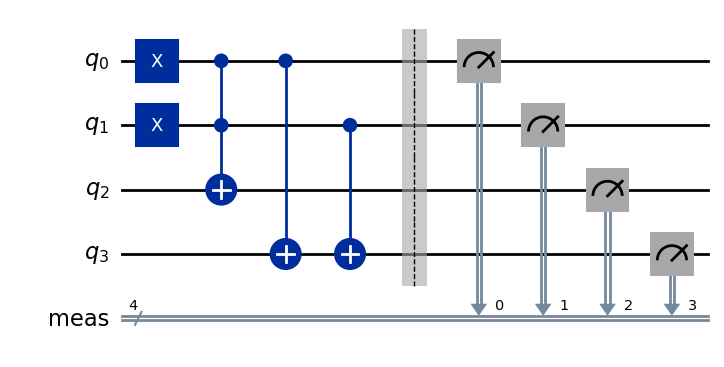

In [8]:
qc.draw('mpl')

<a id="task2"></a>
### Task 2 

Add the three bits stored in qubits 0-2 and store the sum on qubits 3-4.

<h3> Solution </h3>

In [2]:
def initialize(qc, input):
    for i in range(len(input)):
        if input[i] == '1':
            qc.x(i)

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

for input in  ['000','001','010','011','100','101','110','111']:
    qc = QuantumCircuit(5)
    initialize(qc, input)

    # add qubit 0
    qc.ccx(0, 3, 4)
    qc.cx(0, 3)

    # add qubit 1
    qc.ccx(1, 3, 4)
    qc.cx(1, 3)

    # add qubit 2
    qc.ccx(2, 3, 4)
    qc.cx(2, 3)
    qc.measure_all()

    job = AerSimulator().run(qc, shots=1)
    counts = job.result().get_counts(qc)
    
    # print the sum
    print("Input:", input)
    print("Added bits:", input[0] , "and", input[1], "and", input[2])
    print("The sum should be equal to", int(input[0])+int(input[1])+int(input[2]))
    cout = list(counts.keys())[0][0]
    sum_bit = list(counts.keys())[0][1]
    print("According to quantum circuit: ")  
    print("Measurement output:", counts)
    print("Cout and Sum in binary:", cout + sum_bit)
    print("Cout and Sum in decimal:", 2*int(cout) + int(sum_bit))
    print("\n")

NameError: name 'initialize' is not defined

<a id="task3"></a>
### Task 3

By using the above idea, add the values of seven bits, namely $ q_0,\ldots,q_6 $, and write the results on the qubits $ q_7,q_8, q_9 $, where $q_7$ is the least significant and $q_9$ is the most significant digit.

*Note:*  You may use for-loops instead of adding each qubit one by one.

<h3> Solution </h3>

In [4]:
# Generate the inputs
input_list = [bin(i)[2:].zfill(7) for i in range(0,2**7)]

In [5]:
def initialize(qc, input):
    for i in range(len(input)):
        if input[i] == '1':
            qc.x(i)

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

n = 7 # Starting index of the sum qubits

for input in input_list:
    qc = QuantumCircuit(10, 3)

    #We can do the initialization inside a for loop
    initialize(qc, input)

    #add qubit 0
    qc.cx(0, n)
    
    # add qubit 1
    qc.ccx(1, n, n+1)
    qc.cx(1, n)
    
    # add qubit 2
    qc.ccx(2, n, n+1)
    qc.cx(2, n)
    
    # add qubit 3
    qc.mcx([3, n, n+1], n+2) 
    qc.ccx(3, n, n+1)
    qc.cx(3, n)
    
    # add qubit 4
    qc.mcx([4, n, n+1], n+2)
    qc.ccx(4, n, n+1)
    qc.cx(4, n)
    
    # add qubit 5
    qc.mcx([5, n, n+1], n+2)
    qc.ccx(5, n, n+1)
    qc.cx(5, n)
    
    # add qubit 6
    qc.mcx([6, n, n+1], n+2)
    qc.ccx(6, n, n+1)
    qc.cx(6, n)
    
    qc.measure([n, n+1, n+2], range(3))

    # Simulate
    result =  AerSimulator().run(qc, shots=1).result()
    counts = result.get_counts()

    # print the sum
    print("Input:", input)
    print("The sum should be equal to", sum([int(bit) for bit in input]))
    first_digit = list(counts.keys())[0][0]
    second_digit = list(counts.keys())[0][1]
    third_digit = list(counts.keys())[0][2]
    print("According to quantum circuit: ")  
    print("Measurement output:", counts)
    print("Result in binary:", first_digit + second_digit + third_digit, "= ", int(first_digit)*2**2 + int(second_digit)*2 + int(third_digit))
    print("\n")

Input: 0000000
The sum should be equal to 0
According to quantum circuit: 
Measurement output: {'000': 1}
Result in binary: 000 =  0


Input: 0000001
The sum should be equal to 1
According to quantum circuit: 
Measurement output: {'001': 1}
Result in binary: 001 =  1


Input: 0000010
The sum should be equal to 1
According to quantum circuit: 
Measurement output: {'001': 1}
Result in binary: 001 =  1


Input: 0000011
The sum should be equal to 2
According to quantum circuit: 
Measurement output: {'010': 1}
Result in binary: 010 =  2


Input: 0000100
The sum should be equal to 1
According to quantum circuit: 
Measurement output: {'001': 1}
Result in binary: 001 =  1


Input: 0000101
The sum should be equal to 2
According to quantum circuit: 
Measurement output: {'010': 1}
Result in binary: 010 =  2


Input: 0000110
The sum should be equal to 2
According to quantum circuit: 
Measurement output: {'010': 1}
Result in binary: 010 =  2


Input: 0000111
The sum should be equal to 3
According t

We can use for loops instead of performing each addition seperately.

In [8]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

n = 7

for input in input_list:
    qc = QuantumCircuit(10, 3)

    #We can do the initialization inside a for loop
    initialize(qc, input)
            
    # add qubit 0        
    qc.cx(0, n)
    
    # add qubits 1-2
    for j in range(1,3):
        qc.ccx(j, n, n+1)
        qc.cx(j, n)
    
    # add qubits 3-6
    for j in range(3,7):
        qc.mcx([j, n, n+1], n+2)
        qc.ccx(j, n, n+1)
        qc.cx(j, n)

    qc.measure([n, n+1, n+2], range(3))

    # Simulate
    result =  AerSimulator().run(qc, shots=1).result()
    counts = result.get_counts()

    # print the sum
    print("Input:", input)
    print("The sum should be equal to", sum([int(bit) for bit in input]))
    first_digit = list(counts.keys())[0][0]
    second_digit = list(counts.keys())[0][1]
    third_digit = list(counts.keys())[0][2]
    print("According to quantum circuit: ")  
    print("Measurement output:", counts)
    print("Result in binary:", first_digit + second_digit + third_digit, "= ", int(first_digit)*2**2 + int(second_digit)*2 + int(third_digit))
    print("\n")

Input: 0000000
The sum should be equal to 0
According to quantum circuit: 
Measurement output: {'000': 1}
Result in binary: 000 =  0


Input: 0000001
The sum should be equal to 1
According to quantum circuit: 
Measurement output: {'001': 1}
Result in binary: 001 =  1


Input: 0000010
The sum should be equal to 1
According to quantum circuit: 
Measurement output: {'001': 1}
Result in binary: 001 =  1


Input: 0000011
The sum should be equal to 2
According to quantum circuit: 
Measurement output: {'010': 1}
Result in binary: 010 =  2


Input: 0000100
The sum should be equal to 1
According to quantum circuit: 
Measurement output: {'001': 1}
Result in binary: 001 =  1


Input: 0000101
The sum should be equal to 2
According to quantum circuit: 
Measurement output: {'010': 1}
Result in binary: 010 =  2


Input: 0000110
The sum should be equal to 2
According to quantum circuit: 
Measurement output: {'010': 1}
Result in binary: 010 =  2


Input: 0000111
The sum should be equal to 3
According t

<a id="task4"></a>
### Task 4
Implement the algorithm that checks whether the first two qubits store the binary representation of number 6. Store the output on qubit 3.

<h3> Solution </h3>

In [17]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(4, 4)

# set qubits to 6 = 110_2:  q_2 q_1 q_0
qc.x(2)
qc.x(1)

# sanity check: set qubits to 3
# qc.x(1)
# qc.x(0)

qc.x(0)
qc.mcx([0, 1, 2], 3)
qc.x(0)

qc.measure(list(range(4)), list(range(4)))

result = AerSimulator().run(qc, shots=1).result()
counts = result.get_counts()

print("Measurement output:", counts)

if list(counts.keys())[0][0] == '1':
    print("The number equals 6")
else:
    print("The number does not equal 6")

if not (list(counts.keys())[0][1] == '1' and list(counts.keys())[0][2] == '1' and list(counts.keys())[0][3] == '0'):
     print("The input qubits are not recovered")
else:
     print("The input qubits are recovered")
print(qc)

Measurement output: {'1110': 1}
The number equals 6
The input qubits are recovered
     ┌───┐     ┌───┐      ┌─┐
q_0: ┤ X ├──■──┤ X ├──────┤M├
     ├───┤  │  └┬─┬┘      └╥┘
q_1: ┤ X ├──■───┤M├────────╫─
     ├───┤  │   └╥┘ ┌─┐    ║ 
q_2: ┤ X ├──■────╫──┤M├────╫─
     └───┘┌─┴─┐  ║  └╥┘┌─┐ ║ 
q_3: ─────┤ X ├──╫───╫─┤M├─╫─
          └───┘  ║   ║ └╥┘ ║ 
c: 4/════════════╩═══╩══╩══╩═
                 1   2  3  0 


<a id="task5"></a>

### Task 5
Design a circuit that checks whether the first three qubits store either 4 or 5 in binary. 

*Hint:* Note that $4=100_2$ and $5=101_2$, hence $\ket{q_2}$ has to be set to $\ket{1}$, and $\ket{q_1}$ to $\ket{0}_2$, while $\ket{q_0}$ can be arbitrary.

*Hint:* Don't forget to recover the original state of the qubit by applying $X$ gate!

<h3> Solution </h3>

In [24]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(4, 4)

qc.h(list(range(3)))

qc.x(1)
qc.ccx(1, 2, 3)
qc.x(1)

qc.measure(list(range(4)), list(range(4)))
result = AerSimulator().run(qc, shots=1).result()

counts = result.get_counts()
print("Measurement output:", counts)

number_measured = 2**2*int(list(counts.keys())[0][1]) + 2**1*int(list(counts.keys())[0][2]) + 2**0*int(list(counts.keys())[0][3])
print("Number measured:", number_measured)
if int(list(counts.keys())[0][0]) == 1:
    print("It is 4 or 5")
else:
    print("It is neither 4 nor 5")

Measurement output: {'1100': 1}
Number measured: 4
It is 4 or 5
